In [1]:
from google.colab import drive
drive.mount('/content/drive')

import json
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import Counter

MODEL_DIR  = "/content/drive/MyDrive/omr_model_2500"
VOCAB_PATH = f"{MODEL_DIR}/vocab.json"
MODEL_PATH = f"{MODEL_DIR}/best_model.keras"

with open(VOCAB_PATH, "r", encoding="utf-8") as f:
    save_data = json.load(f)

vocab      = save_data["vocab"]
idx2tok    = {int(k): v for k, v in save_data["idx2tok"].items()}
VOCAB_SIZE = save_data["VOCAB_SIZE"]
BLANK_IDX  = save_data["BLANK_IDX"]

print(f"Vocabulario: {VOCAB_SIZE} tokens  |  BLANK en índice: {BLANK_IDX}")

model = tf.keras.models.load_model(MODEL_PATH)
print("Modelo cargado ✓")

Mounted at /content/drive
Vocabulario: 802 tokens  |  BLANK en índice: 801
Modelo cargado ✓


In [2]:
IMG_HEIGHT = 128

def preprocess_image(img_path, height=IMG_HEIGHT):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"No se pudo leer: {img_path}")
    h, w = img.shape
    new_w = max(1, int(w * height / h))
    img = cv2.resize(img, (new_w, height))
    img = img.astype(np.float32) / 255.0
    img = 1.0 - img
    return img

def predict_image(model, img_path, idx2tok, blank_idx):
    img = preprocess_image(img_path)
    X   = img[np.newaxis, :, :, np.newaxis]

    y_pred    = model(X, training=False)
    T         = y_pred.shape[1]
    input_len = np.array([T])

    decoded, log_probs = tf.keras.backend.ctc_decode(
        y_pred, input_len, greedy=True
    )
    raw_tokens = decoded[0].numpy()[0]
    tokens = [
        idx2tok[t]
        for t in raw_tokens
        if t >= 0 and t != blank_idx and t in idx2tok
    ]
    confidence = float(-log_probs.numpy()[0][0])
    return tokens, confidence, img

print("Funciones listas ✓")

Funciones listas ✓


In [12]:
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print(f"Imagen recibida: {img_path}")

tokens, confidence, img_proc = predict_image(model, img_path, idx2tok, BLANK_IDX)

print(f"\n{'='*60}")
print(f"  Tokens detectados : {len(tokens)}")
print(f"  Log-probabilidad  : {confidence:.4f}")
print(f"{'='*60}")
print("\nSECUENCIA PREDICHA:")
print(" ".join(tokens))
print(f"{'='*60}")

Saving Captura de pantalla 2026-05-21 181334.png to Captura de pantalla 2026-05-21 181334.png
Imagen recibida: Captura de pantalla 2026-05-21 181334.png

  Tokens detectados : 38
  Log-probabilidad  : -24.7403

SECUENCIA PREDICHA:
keySignature-DM note-G4_sixteenth note-A4_sixteenth note-Bb4_sixteenth barline note-C5_sixteenth note-B4_sixteenth note-C5_sixteenth note-D5_sixteenth note-E5_sixteenth note-F5_sixteenth barline note-G5_sixteenth note-G5_sixteenth note-G5_sixteenth note-G5_sixteenth note-G5_sixteenth note-G5_sixteenth note-G5_sixteenth note-G5_sixteenth note-F5_sixteenth note-F5_sixteenth note-F5_sixteenth note-F5_sixteenth barline note-G5_sixteenth note-G5_sixteenth note-G5_sixteenth note-G5_sixteenth note-G5_sixteenth note-G5_sixteenth note-G5_sixteenth note-G5_sixteenth note-F5_sixteenth note-F5_sixteenth note-F5_sixteenth note-F5_sixteenth barline


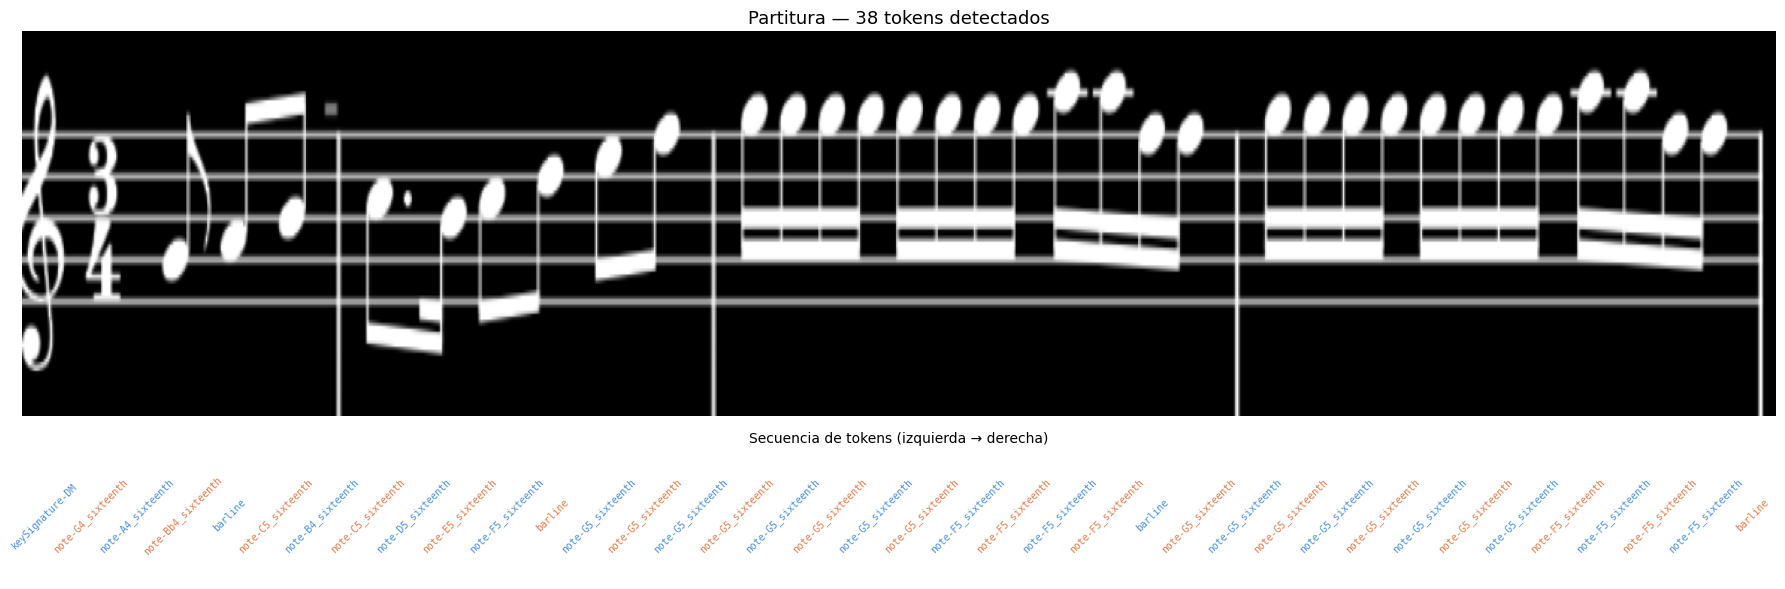

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(18, 6),
                         gridspec_kw={"height_ratios": [3, 1]})

axes[0].imshow(img_proc, cmap="gray", aspect="auto")
axes[0].set_title(f"Partitura — {len(tokens)} tokens detectados", fontsize=13)
axes[0].axis("off")

axes[1].set_xlim(0, max(len(tokens), 1))
axes[1].set_ylim(0, 1)
axes[1].axis("off")
axes[1].set_facecolor("#f8f8f8")

for i, tok in enumerate(tokens):
    color = "#4a90d9" if i % 2 == 0 else "#e07b4a"
    axes[1].text(i + 0.5, 0.5, tok, ha="center", va="center",
                 fontsize=7, color=color, rotation=45, fontfamily="monospace")

axes[1].set_title("Secuencia de tokens (izquierda → derecha)", fontsize=10)
plt.tight_layout()
plt.show()

In [14]:
import xml.etree.ElementTree as ET
from xml.dom import minidom
from google.colab import files

def tokens_to_musicxml(tokens, title="OMR Result"):

    DURATION_MAP = {
        "double_whole":  ("breve",   8.0),
        "whole":         ("whole",   4.0),
        "half":          ("half",    2.0),
        "quarter":       ("quarter", 1.0),
        "eighth":        ("eighth",  0.5),
        "sixteenth":     ("16th",    0.25),
        "thirty_second": ("32nd",    0.125),
        "sixty_fourth":  ("64th",    0.0625),
    }

    ALTER_PREFIX = {
        "Bb": ("B", -1), "Ab": ("A", -1), "Eb": ("E", -1),
        "Db": ("D", -1), "Gb": ("G", -1), "Cb": ("C", -1), "Fb": ("F", -1),
        "B#": ("B",  1), "C#": ("C",  1), "D#": ("D",  1), "E#": ("E",  1),
        "F#": ("F",  1), "G#": ("G",  1), "A#": ("A",  1),
        "A":  ("A",  0), "B":  ("B",  0), "C":  ("C",  0), "D":  ("D",  0),
        "E":  ("E",  0), "F":  ("F",  0), "G":  ("G",  0),
    }

    KEY_FIFTHS = {
        "CM":0,  "GM":1,  "DM":2,  "AM":3,  "EM":4,  "BM":5,
        "FM":-1, "BbM":-2,"EbM":-3,"AbM":-4,"DbM":-5,"GbM":-6,
    }

    CLEF_MAP = {
        "G1":("G","1"), "G2":("G","2"),
        "F3":("F","3"), "F4":("F","4"),
        "C1":("C","1"), "C2":("C","2"),
        "C3":("C","3"), "C4":("C","4"),
        "C5":("C","5"),
    }

    def parse_pitch(pitch_str):
        for prefix in sorted(ALTER_PREFIX.keys(), key=len, reverse=True):
            if pitch_str.startswith(prefix):
                step, alter = ALTER_PREFIX[prefix]
                rest = pitch_str[len(prefix):]
                octave = int(rest) if rest.isdigit() else 4
                return step, alter, octave
        return None, None, None

    def parse_duration(dur_str):
        fermata = dur_str.endswith("_fermata")
        s = dur_str.replace("_fermata", "")

        dots = 0
        if s.endswith(".."):
            dots = 2
            s = s[:-2]
        elif s.endswith("."):
            dots = 1
            s = s[:-1]

        if s not in DURATION_MAP:
            return None, None, None, None

        dur_type, base_beats = DURATION_MAP[s]
        beats = base_beats
        add = base_beats / 2
        for _ in range(dots):
            beats += add
            add /= 2

        return dur_type, beats, dots, fermata

    def parse_note_token(tok, prefix="note-"):
        body = tok[len(prefix):]
        if "_" not in body:
            return None
        pitch_str, dur_str = body.split("_", 1)
        step, alter, octave = parse_pitch(pitch_str)
        if step is None:
            return None
        dur_type, beats, dots, fermata = parse_duration(dur_str)
        if dur_type is None:
            return None
        return {"step": step, "alter": alter, "octave": octave,
                "type": dur_type, "beats": beats, "dots": dots,
                "fermata": fermata}

    def parse_rest_token(tok):
        dur_str = tok[5:]
        dur_type, beats, dots, fermata = parse_duration(dur_str)
        if dur_type is None:
            return None
        return {"type": dur_type, "beats": beats, "dots": dots, "fermata": fermata}

    # ── Estado global ─────────────────────────────────────────────────────────
    DIVISIONS = 16
    beats_per = 4.0
    beat_type = 4
    fifths    = 0
    clef_sign = "G"
    clef_line = "2"

    measures        = []
    current_measure = []
    beat_accum      = 0.0

    def flush():
        nonlocal beat_accum
        if current_measure:
            measures.append(list(current_measure))
            current_measure.clear()
            beat_accum = 0.0

    # ── Recorrer tokens ───────────────────────────────────────────────────────
    for tok in tokens:
        tok = tok.strip()

        if tok.startswith("clef-"):
            code = tok[5:]
            if code in CLEF_MAP:
                clef_sign, clef_line = CLEF_MAP[code]
            continue

        if tok.startswith("keySignature-"):
            key = tok[13:]
            fifths = KEY_FIFTHS.get(key, 0)
            continue

        if tok.startswith("timeSignature-"):
            sig = tok[14:]
            if sig == "C":
                beats_per, beat_type = 4.0, 4
            elif sig == "C/":
                beats_per, beat_type = 2.0, 2
            else:
                try:
                    b, bt = sig.split("/")
                    beats_per = float(b)
                    beat_type = int(bt)
                except Exception:
                    pass
            continue

        if tok.startswith("multirest-"):
            try:
                n = int(tok[10:])
            except Exception:
                n = 1
            flush()
            measures.append([("multirest", {"count": n})])
            beat_accum = 0.0
            continue

        if tok == "barline":
            flush()
            continue

        if tok == "tie":
            for i in range(len(current_measure) - 1, -1, -1):
                kind, data = current_measure[i]
                if kind == "note":
                    data["tie_stop"] = True
                    break
            continue

        if tok.startswith("note-"):
            parsed = parse_note_token(tok, "note-")
            if parsed:
                current_measure.append(("note", parsed))
                beat_accum += parsed["beats"]
                if beat_accum >= beats_per - 0.001:
                    flush()
            continue

        if tok.startswith("gracenote-"):
            parsed = parse_note_token(tok, "gracenote-")
            if parsed:
                current_measure.append(("grace", parsed))
            continue

        if tok.startswith("rest-"):
            parsed = parse_rest_token(tok)
            if parsed:
                current_measure.append(("rest", parsed))
                beat_accum += parsed["beats"]
                if beat_accum >= beats_per - 0.001:
                    flush()
            continue

    if current_measure:
        flush()

    if not measures:
        measures = [[]]

    # ── Construir XML ─────────────────────────────────────────────────────────
    root_el = ET.Element("score-partwise", version="3.1")

    work = ET.SubElement(root_el, "work")
    ET.SubElement(work, "work-title").text = title

    ident = ET.SubElement(root_el, "identification")
    enc   = ET.SubElement(ident, "encoding")
    ET.SubElement(enc, "software").text = "OMR CRNN Model"

    part_list = ET.SubElement(root_el, "part-list")
    sp = ET.SubElement(part_list, "score-part", id="P1")
    ET.SubElement(sp, "part-name").text = "Music"

    part_el = ET.SubElement(root_el, "part", id="P1")

    real_num = 1
    for m_idx, events in enumerate(measures):
        is_multirest = len(events) == 1 and events[0][0] == "multirest"
        meas_el = ET.SubElement(part_el, "measure", number=str(real_num))
        if not is_multirest:
            real_num += 1

        # Atributos — siempre en el primer compás, y si es multirest va todo junto
        if m_idx == 0:
            attrs = ET.SubElement(meas_el, "attributes")
            ET.SubElement(attrs, "divisions").text = str(DIVISIONS)
            key_el = ET.SubElement(attrs, "key")
            ET.SubElement(key_el, "fifths").text = str(fifths)
            time_el = ET.SubElement(attrs, "time")
            ET.SubElement(time_el, "beats").text = str(int(beats_per))
            ET.SubElement(time_el, "beat-type").text = str(beat_type)
            clef_el = ET.SubElement(attrs, "clef")
            ET.SubElement(clef_el, "sign").text = clef_sign
            ET.SubElement(clef_el, "line").text = clef_line

            # Si además es multirest, el measure-style va DENTRO del mismo attributes
            if is_multirest:
                n = events[0][1]["count"]
                meas_el.set("implicit", "yes")
                ms = ET.SubElement(attrs, "measure-style")
                mr = ET.SubElement(ms, "multiple-rest")
                mr.text = str(n)
                note_el = ET.SubElement(meas_el, "note")
                ET.SubElement(note_el, "rest", {"measure": "yes"})
                ET.SubElement(note_el, "duration").text = str(int(beats_per * DIVISIONS))
                ET.SubElement(note_el, "type").text = "whole"
                continue

        for kind, data in events:

            if kind == "multirest":
                n = data["count"]
                meas_el.set("implicit", "yes")
                # measure-style en su propio attributes (compases que no son el primero)
                attrs2 = ET.SubElement(meas_el, "attributes")
                ms = ET.SubElement(attrs2, "measure-style")
                mr = ET.SubElement(ms, "multiple-rest")
                mr.text = str(n)
                note_el = ET.SubElement(meas_el, "note")
                ET.SubElement(note_el, "rest", {"measure": "yes"})
                ET.SubElement(note_el, "duration").text = str(int(beats_per * DIVISIONS))
                ET.SubElement(note_el, "type").text = "whole"
                continue

            note_el = ET.SubElement(meas_el, "note")

            # Grace note
            if kind == "grace":
                ET.SubElement(note_el, "grace")

            # Pitch o rest
            if kind in ("note", "grace"):
                pitch_el = ET.SubElement(note_el, "pitch")
                ET.SubElement(pitch_el, "step").text = data["step"]
                if data["alter"] != 0:
                    ET.SubElement(pitch_el, "alter").text = str(data["alter"])
                ET.SubElement(pitch_el, "octave").text = str(data["octave"])
            else:
                ET.SubElement(note_el, "rest")

            # Duración (grace notes no llevan duration en MusicXML)
            if kind != "grace":
                dur_units = max(1, int(round(data["beats"] * DIVISIONS)))
                ET.SubElement(note_el, "duration").text = str(dur_units)

            ET.SubElement(note_el, "type").text = data["type"]

            for _ in range(data.get("dots", 0)):
                ET.SubElement(note_el, "dot")

            if data.get("fermata"):
                notations = ET.SubElement(note_el, "notations")
                ET.SubElement(notations, "fermata")

            if data.get("tie_stop"):
                ET.SubElement(note_el, "tie", {"type": "stop"})
                notations = note_el.find("notations")
                if notations is None:
                    notations = ET.SubElement(note_el, "notations")
                ET.SubElement(notations, "tied", {"type": "stop"})

    return root_el


def save_musicxml(root_el, path):
    raw    = ET.tostring(root_el, encoding="unicode")
    pretty = minidom.parseString(raw).toprettyxml(indent="  ")
    lines  = pretty.split("\n")
    body   = "\n".join(lines[1:]) if lines[0].startswith("<?xml") else pretty
    header = (
        '<?xml version="1.0" encoding="UTF-8"?>\n'
        '<!DOCTYPE score-partwise PUBLIC "-//Recordare//DTD MusicXML 3.1 Partwise//EN"\n'
        '  "http://www.musicxml.org/dtds/partwise.dtd">\n'
    )
    with open(path, "w", encoding="utf-8") as f:
        f.write(header + body)
    print(f"MusicXML guardado: {path}")


# ── Ejecutar ──────────────────────────────────────────────────────────────────
xml_root = tokens_to_musicxml(tokens, title="Mi Partitura OMR")
xml_path = "/content/partitura_omr.musicxml"
save_musicxml(xml_root, xml_path)

num_measures = len(list(xml_root.find('.//part')))
print(f"Tokens procesados : {len(tokens)}")
print(f"Compases generados: {num_measures}")

files.download(xml_path)
print("Abre el .musicxml en MuseScore 4 con File → Open")

MusicXML guardado: /content/partitura_omr.musicxml
Tokens procesados : 38
Compases generados: 4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Abre el .musicxml en MuseScore 4 con File → Open
